# ДЗ 4 — Генерация данных

По условию:
1. Датасет для классификации изображений.
2. Автокодировщик: обучение, кривая, реконструкции.
3. Gaussian и SMOTE в пространстве изображений и в latent AE.
4. Остаток ИСУ mod 3 = **0** → **VAE** (условный VAE).
5. Условная генерация и смесь классов.

Текущая версия: **Food-101 subset** из **6** классов (ресайз `64×64` RGB). Резерв на FashionMNIST: `hw4_fashionmnist_backup.ipynb`.


## Импорты и воспроизводимость

Фиксируем `RANDOM_STATE = 1216` для `random` / `numpy` / `torch`.


In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms

RANDOM_STATE = 1216
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# Food-101 subset: ресайз до фиксированного RGB кадра (CHW после ToTensor)
IMG_H = 64
IMG_W = 64
IMG_CHANNELS = 3
FLAT_LEN = IMG_H * IMG_W * IMG_CHANNELS

# Работаем на 6 классах Food-101 (фиксированный список в ячейке данных)
NUM_CLASSES = 6

# Обучение (общие)
EPOCHS = 50
BATCH_SIZE = 128

# Latent
Z_DIM = 16

# cVAE: настройки баланса резкость/регуляризация
KL_BETA = 2.5e-3
RECON_L1_WEIGHT = 0.7
GEN_TEMPERATURE = 0.65

# Численная стабильность для диагональной ковариации
COV_EPS = 1e-5

# Подвыборки и визуализация
N_GAUSS_SUBSET = 8000
N_VIZ_SAMPLES = 12
N_RECON_SAMPLES = 10
LATENT_COLLECT_MAX_BATCHES = 30

# Условная генерация: все 6 классов (0..5), по 5 сэмплов → сетка 6×5
GEN_CLASS_MIN = 0
GEN_CLASS_MAX = 5
SAMPLES_PER_GEN_CLASS = 5
GEN_GRID_COLS = 5

# Пул классов для скрещивания (индексы 0..5)
MIX_POOL_CLASSES = (0, 1, 2, 5)
N_MIX_SAMPLES = 20

# Размеры фигур (дюймы) — только там, где фигура используется дважды
FIG_CURVE = (6, 4)
FIG_GAUSS_SMOTE = (18, 4)


def tensor_chw_to_numpy_hwc(image: torch.Tensor) -> np.ndarray:
    """Тензор (C,H,W) в [0,1] -> массив (H,W,C) для imshow."""
    return np.clip(image.detach().cpu().permute(1, 2, 0).numpy(), 0.0, 1.0)


device: cuda


## П. 1. Данные для классификации

**Текст пункта из условия:** Выберите любой набор данных для классификации изображений. Желательно, чтобы изображения были небольшого размера, а классов было не так много.

Используем **Food-101** с **6** фиксированными классами: изображения приводим к `64×64` RGB (`torchvision.datasets.Food101`) и переиндексируем метки в диапазон `0..5`.

In [2]:
transform = transforms.Compose([
    transforms.Resize((IMG_H, IMG_W)),
    transforms.ToTensor(),
])

full_train_dataset = datasets.Food101(root="./data_food101", split="train", download=True, transform=transform)
full_test_dataset = datasets.Food101(root="./data_food101", split="test", download=True, transform=transform)

INTERESTING_CLASS_NAMES = [
    "sushi",
    "hamburger",
    "pizza",
    "caesar_salad",
    "chocolate_cake",
    "ice_cream",
]
assert len(INTERESTING_CLASS_NAMES) == NUM_CLASSES

class_to_idx = full_train_dataset.class_to_idx
selected_original_ids = [class_to_idx[name] for name in INTERESTING_CLASS_NAMES]
original_to_new = {old_id: new_id for new_id, old_id in enumerate(selected_original_ids)}
allowed_id_set = set(selected_original_ids)
CLASS_NAMES = INTERESTING_CLASS_NAMES


class Food101FilteredRemapped(Dataset):
    def __init__(self, base_dataset: datasets.Food101, allowed_ids: set[int], remap_dict: dict[int, int]) -> None:
        self.base_dataset = base_dataset
        self.remap_dict = remap_dict
        self.indices = [i for i, y in enumerate(base_dataset._labels) if y in allowed_ids]

    def __len__(self) -> int:
        return len(self.indices)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, int]:
        image, original_label = self.base_dataset[self.indices[index]]
        return image, self.remap_dict[int(original_label)]


train_dataset = Food101FilteredRemapped(full_train_dataset, allowed_id_set, original_to_new)
test_dataset = Food101FilteredRemapped(full_test_dataset, allowed_id_set, original_to_new)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("train:", len(train_dataset), "test:", len(test_dataset), "classes:", NUM_CLASSES)
print("пример классов:", CLASS_NAMES[:8])


train: 4500 test: 1500 classes: 6
пример классов: ['sushi', 'hamburger', 'pizza', 'caesar_salad', 'chocolate_cake', 'ice_cream']


## П. 2. Автокодировщик

**Текст пункта из условия:** Постройте модель автокодировщика и обучите её. Постройте кривую обучения. Провизуализируйте, как автокодировщик восстанавливает изображения.

Блок: свёрточный энкодер `x → h → z`, декодер `z → h' → x̂` (ConvTranspose), минимизируем `MSE(x̂, x)`.


In [3]:
# Свёрточный AE: локальные признаки → вектор латента → снова карта признаков → изображение.
class AutoEncoder(nn.Module):
    def __init__(self, latent_dim: int) -> None:
        super().__init__()
        self.latent_dim = latent_dim
        self.enc_conv = nn.Sequential(
            nn.Conv2d(IMG_CHANNELS, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
        )
        self.enc_spatial = IMG_H // 16
        self.enc_flat = 256 * self.enc_spatial * self.enc_spatial
        self.fc_enc = nn.Linear(self.enc_flat, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, self.enc_flat)
        self.dec_conv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, IMG_CHANNELS, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, images: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        h = self.enc_conv(images)
        latent = self.fc_enc(h.flatten(1))
        h_dec = self.fc_dec(latent).view(-1, 256, self.enc_spatial, self.enc_spatial)
        recon = self.dec_conv(h_dec)
        return recon, latent

    def decode_latent(self, z: torch.Tensor) -> torch.Tensor:
        """Декодирование из латента (B, latent_dim) → изображение (B, C, H, W). Для п.3 в latent-пространстве."""
        h_dec = self.fc_dec(z).view(-1, 256, self.enc_spatial, self.enc_spatial)
        return self.dec_conv(h_dec)


ae = AutoEncoder(latent_dim=32).to(device)
opt_ae = torch.optim.Adam(ae.parameters(), lr=1e-3)

ae_history = []

for epoch in range(EPOCHS):
    ae.train()
    total_loss = 0.0
    total_count = 0
    for images, _ in train_loader:
        images = images.to(device)
        recon, _ = ae(images)
        loss = F.mse_loss(recon, images)
        opt_ae.zero_grad()
        loss.backward()
        opt_ae.step()
        total_loss += float(loss.item()) * images.size(0)
        total_count += images.size(0)
    epoch_loss = total_loss / max(total_count, 1)
    ae_history.append(epoch_loss)
    print(f"AE epoch {epoch+1}: loss={epoch_loss:.5f}")


AE epoch 1: loss=0.07016
AE epoch 2: loss=0.05582
AE epoch 3: loss=0.04168
AE epoch 4: loss=0.03376
AE epoch 5: loss=0.02931
AE epoch 6: loss=0.02645
AE epoch 7: loss=0.02462
AE epoch 8: loss=0.02370
AE epoch 9: loss=0.02255
AE epoch 10: loss=0.02193
AE epoch 11: loss=0.02126
AE epoch 12: loss=0.02066
AE epoch 13: loss=0.02057
AE epoch 14: loss=0.02000
AE epoch 15: loss=0.01992
AE epoch 16: loss=0.01959
AE epoch 17: loss=0.01937
AE epoch 18: loss=0.01951
AE epoch 19: loss=0.01897
AE epoch 20: loss=0.01881
AE epoch 21: loss=0.01884
AE epoch 22: loss=0.01851
AE epoch 23: loss=0.01823
AE epoch 24: loss=0.01807
AE epoch 25: loss=0.01813
AE epoch 26: loss=0.01778
AE epoch 27: loss=0.01771
AE epoch 28: loss=0.01757
AE epoch 29: loss=0.01715
AE epoch 30: loss=0.01698
AE epoch 31: loss=0.01723
AE epoch 32: loss=0.01693
AE epoch 33: loss=0.01675
AE epoch 34: loss=0.01653
AE epoch 35: loss=0.01646
AE epoch 36: loss=0.01621
AE epoch 37: loss=0.01634
AE epoch 38: loss=0.01620
AE epoch 39: loss=0.0

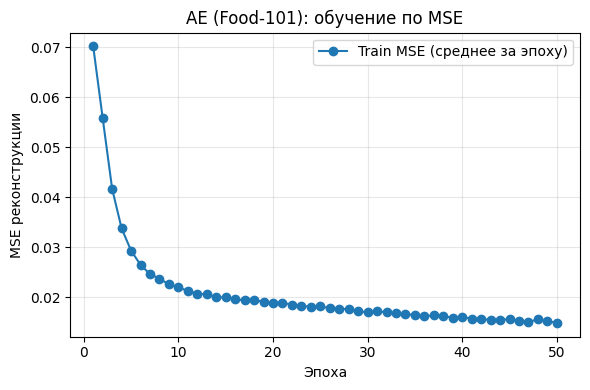

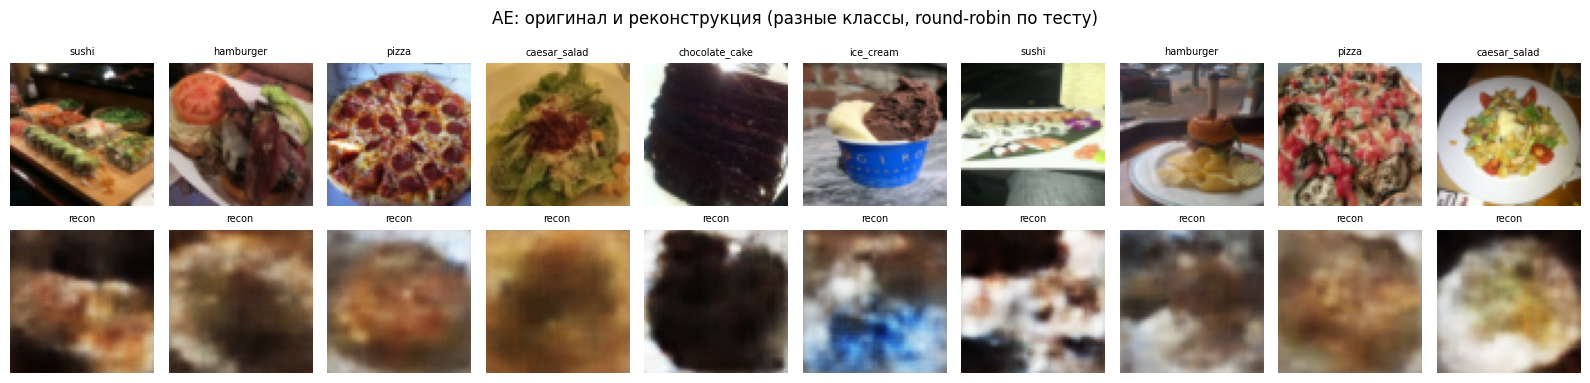

In [4]:
plt.figure(figsize=FIG_CURVE)
plt.plot(np.arange(1, len(ae_history) + 1), ae_history, marker="o", label="Train MSE (среднее за эпоху)")
plt.xlabel("Эпоха")
plt.ylabel("MSE реконструкции")
plt.title("AE (Food-101): обучение по MSE")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

ae.eval()
# Примеры с разных классов: пул по классам из test_loader, затем round-robin.
by_class: dict[int, list[torch.Tensor]] = {c: [] for c in range(NUM_CLASSES)}
with torch.inference_mode():
    for images, labels in test_loader:
        for i in range(images.size(0)):
            c = int(labels[i])
            if len(by_class[c]) < 8:
                by_class[c].append(images[i].clone())
        need = max(1, (N_RECON_SAMPLES + NUM_CLASSES - 1) // NUM_CLASSES)
        if min(len(by_class[c]) for c in range(NUM_CLASSES)) >= need:
            break

sample_images_list: list[torch.Tensor] = []
sample_labels_list: list[int] = []
round_idx = 0
while len(sample_images_list) < N_RECON_SAMPLES and round_idx < 20:
    for c in range(NUM_CLASSES):
        if len(sample_images_list) >= N_RECON_SAMPLES:
            break
        if round_idx < len(by_class[c]):
            sample_images_list.append(by_class[c][round_idx])
            sample_labels_list.append(c)
    round_idx += 1

sample_images = torch.stack(sample_images_list, dim=0).to(device)
with torch.inference_mode():
    recon_images, _ = ae(sample_images)

fig, axes = plt.subplots(2, N_RECON_SAMPLES, figsize=(16, 4))
for idx in range(N_RECON_SAMPLES):
    axes[0, idx].imshow(tensor_chw_to_numpy_hwc(sample_images[idx]))
    axes[0, idx].axis("off")
    lbl = int(sample_labels_list[idx])
    axes[0, idx].set_title(f"{CLASS_NAMES[lbl][:14]}", fontsize=7)

    axes[1, idx].imshow(tensor_chw_to_numpy_hwc(recon_images[idx]))
    axes[1, idx].axis("off")
    axes[1, idx].set_title("recon", fontsize=7)

plt.suptitle("AE: оригинал и реконструкция (разные классы, round-robin по тесту)")
plt.tight_layout()
plt.show()


## П. 3. Gaussian и SMOTE

**Текст пункта из условия:** Провизуализируйте, как Гауссова модель и SMOTE генерируют изображения в пространстве изображений и в скрытом пространстве автокодировщика. Для пространства изображений (если они большого размера) допускается использовать упрощенную Гауссову модель.

- Gaussian: сэмплы из `N(μ, Σ)` (упрощённо диагональ по признакам).
- SMOTE-подобно: `x_new = x_i + λ(x_j - x_i)`, `λ ∈ [0,1]`.

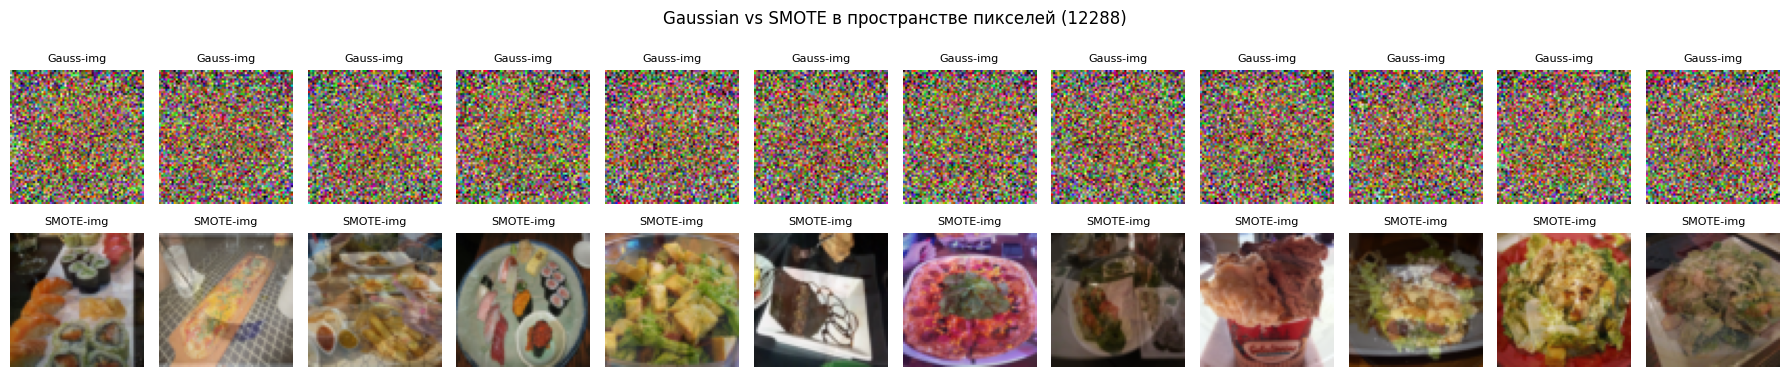

In [5]:
def sample_diagonal_gaussian(mu: np.ndarray, cov_diag: np.ndarray, n_samples: int) -> np.ndarray:
    """Сэмплы из N(mu, diag(cov_diag)) через независимые нормали по координатам."""
    rng = np.random.default_rng(RANDOM_STATE)
    return rng.normal(loc=mu, scale=np.sqrt(cov_diag), size=(n_samples, mu.shape[0]))


def sample_smote(features: np.ndarray, sample_count: int) -> np.ndarray:
    """SMOTE-подобная интерполяция между двумя случайными объектами в признаковом пространстве."""
    rng = np.random.default_rng(RANDOM_STATE)
    n = len(features)
    out = []
    for _ in range(sample_count):
        idx_a = int(rng.integers(0, n))
        idx_b = int(rng.integers(0, n))
        lam = float(rng.random())
        x_new = features[idx_a] + lam * (features[idx_b] - features[idx_a])
        out.append(x_new)
    return np.stack(out)


# Векторы пикселей в порядке CHW (как после ToTensor)
flat_chunks = []
seen = 0
for images, _ in train_loader:
    flat_chunks.append(images.view(images.size(0), -1).cpu().numpy())
    seen += images.size(0)
    if seen >= N_GAUSS_SUBSET:
        break
flat_images = np.vstack(flat_chunks)[:N_GAUSS_SUBSET]

subset_flat = flat_images
mu_img = subset_flat.mean(axis=0)
cov_diag = subset_flat.var(axis=0) + COV_EPS

gaussian_img_samples = sample_diagonal_gaussian(mu_img, cov_diag, N_VIZ_SAMPLES)
gaussian_img_samples = np.clip(gaussian_img_samples, 0.0, 1.0)

smote_img_samples = sample_smote(subset_flat, sample_count=N_VIZ_SAMPLES)
smote_img_samples = np.clip(smote_img_samples, 0.0, 1.0)


def flat_chw_to_hwc(vec: np.ndarray) -> np.ndarray:
    """Один вектор признаков CHW -> (H,W,C) для imshow."""
    chw = vec.reshape(IMG_CHANNELS, IMG_H, IMG_W)
    return np.clip(np.transpose(chw, (1, 2, 0)), 0.0, 1.0)


fig, axes = plt.subplots(2, N_VIZ_SAMPLES, figsize=FIG_GAUSS_SMOTE)
for idx in range(N_VIZ_SAMPLES):
    axes[0, idx].imshow(flat_chw_to_hwc(gaussian_img_samples[idx]))
    axes[0, idx].axis("off")
    axes[0, idx].set_title("Gauss-img", fontsize=8)

    axes[1, idx].imshow(flat_chw_to_hwc(smote_img_samples[idx]))
    axes[1, idx].axis("off")
    axes[1, idx].set_title("SMOTE-img", fontsize=8)

plt.suptitle(f"Gaussian vs SMOTE в пространстве пикселей ({FLAT_LEN})")
plt.tight_layout()
plt.show()


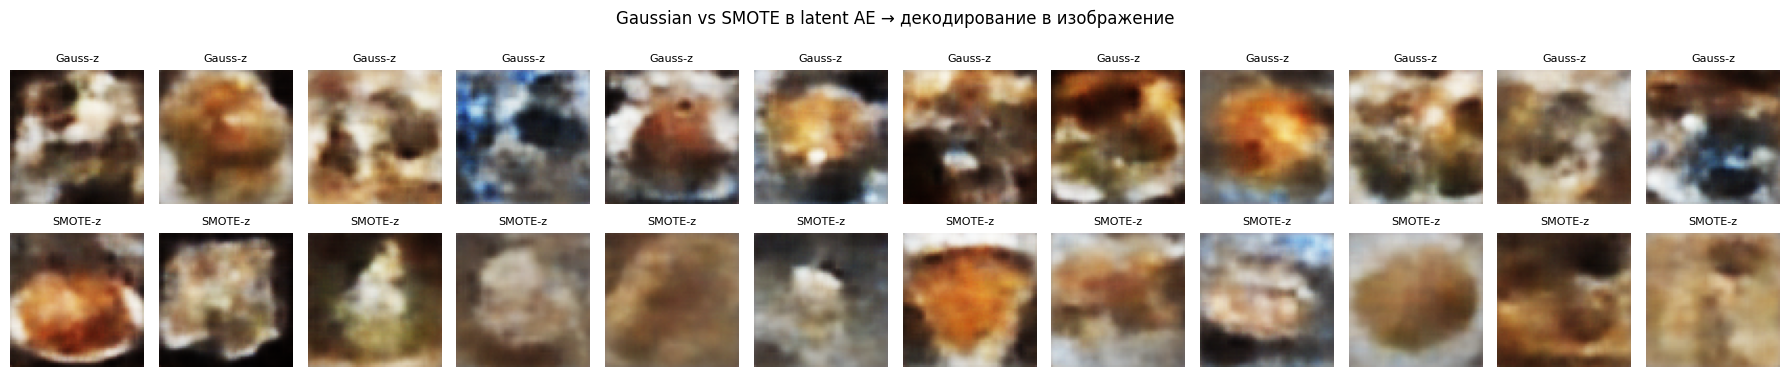

In [6]:
# Скрытое пространство автокодировщика: накопление z по батчам train_loader.
latent_subset = []
ae.eval()
with torch.inference_mode():
    for batch_idx, (images, _) in enumerate(train_loader):
        images = images.to(device)
        _, latent = ae(images)
        latent_subset.append(latent.cpu().numpy())
        if batch_idx >= LATENT_COLLECT_MAX_BATCHES:
            break

latent_subset = np.vstack(latent_subset)
mu_latent = latent_subset.mean(axis=0)
cov_latent_diag = latent_subset.var(axis=0) + COV_EPS

gaussian_latent_samples = sample_diagonal_gaussian(mu_latent, cov_latent_diag, N_VIZ_SAMPLES).astype(np.float32)
smote_latent_samples = sample_smote(latent_subset, sample_count=N_VIZ_SAMPLES).astype(np.float32)

with torch.inference_mode():
    gauss_latent_images = ae.decode_latent(torch.tensor(gaussian_latent_samples, device=device))
    smote_latent_images = ae.decode_latent(torch.tensor(smote_latent_samples, device=device))

fig, axes = plt.subplots(2, N_VIZ_SAMPLES, figsize=FIG_GAUSS_SMOTE)
for idx in range(N_VIZ_SAMPLES):
    axes[0, idx].imshow(tensor_chw_to_numpy_hwc(gauss_latent_images[idx]))
    axes[0, idx].axis("off")
    axes[0, idx].set_title("Gauss-z", fontsize=8)

    axes[1, idx].imshow(tensor_chw_to_numpy_hwc(smote_latent_images[idx]))
    axes[1, idx].axis("off")
    axes[1, idx].set_title("SMOTE-z", fontsize=8)

plt.suptitle("Gaussian vs SMOTE в latent AE → декодирование в изображение")
plt.tight_layout()
plt.show()


## П. 4. Условный VAE (остаток ИСУ = 0)

**Текст пункта из условия:** Вычислите остаток от деления вашего номера ИСУ на 3. Исходя из этого выберите модель:
0 = вариационный автокодировщик или нормализующий поток;
1 = генеративно состязательная сеть;
2 = диффузная модель или Flow Matching.

In [7]:
# Условный VAE: свёрточный энкодер, q(z|x,y) через MLP на [h(x) || y], декодер ConvTranspose.
class ConditionalVAE(nn.Module):
    def __init__(self, z_dim: int, num_classes: int) -> None:
        super().__init__()
        self.z_dim = z_dim
        self.num_classes = num_classes
        self.enc_conv = nn.Sequential(
            nn.Conv2d(IMG_CHANNELS, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
        )
        self.enc_spatial = IMG_H // 16
        self.enc_flat = 256 * self.enc_spatial * self.enc_spatial
        ctx_dim = self.enc_flat + num_classes
        self.fc_ctx = nn.Sequential(
            nn.Linear(ctx_dim, 512),
            nn.ReLU(inplace=True),
        )
        self.mu_head = nn.Linear(512, z_dim)
        self.logvar_head = nn.Linear(512, z_dim)
        self.fc_dec = nn.Linear(z_dim + num_classes, self.enc_flat)
        self.dec_conv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, IMG_CHANNELS, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def encode(self, images: torch.Tensor, labels: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        h = self.enc_conv(images).flatten(1)
        one_hot = F.one_hot(labels, num_classes=self.num_classes).float()
        ctx = self.fc_ctx(torch.cat([h, one_hot], dim=1))
        return self.mu_head(ctx), self.logvar_head(ctx)

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        one_hot = F.one_hot(labels, num_classes=self.num_classes).float()
        h = self.fc_dec(torch.cat([z, one_hot], dim=1)).view(-1, 256, self.enc_spatial, self.enc_spatial)
        return self.dec_conv(h)

    def forward(self, images: torch.Tensor, labels: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        mu, logvar = self.encode(images, labels)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z, labels)
        return recon, mu, logvar


cvae = ConditionalVAE(z_dim=Z_DIM, num_classes=NUM_CLASSES).to(device)
opt_cvae = torch.optim.Adam(cvae.parameters(), lr=1e-3)

cvae_history = []

for epoch in range(EPOCHS):
    cvae.train()
    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0
    total_count = 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        recon, mu, logvar = cvae(images, labels)

        # L1 обычно даёт более резкие контуры, чем чистый MSE.
        l1 = F.l1_loss(recon, images, reduction="mean")
        l2 = F.mse_loss(recon, images, reduction="mean")
        recon_loss = RECON_L1_WEIGHT * l1 + (1.0 - RECON_L1_WEIGHT) * l2
        kl_loss = (-0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum(dim=1)).mean()
        loss = recon_loss + KL_BETA * kl_loss

        opt_cvae.zero_grad()
        loss.backward()
        opt_cvae.step()

        batch_n = images.size(0)
        total_loss += float(loss.item()) * batch_n
        total_recon += float(recon_loss.item()) * batch_n
        total_kl += float(kl_loss.item()) * batch_n
        total_count += batch_n

    epoch_loss = total_loss / max(total_count, 1)
    epoch_recon = total_recon / max(total_count, 1)
    epoch_kl = total_kl / max(total_count, 1)
    cvae_history.append(epoch_loss)
    print(
        f"cVAE epoch {epoch+1}: total={epoch_loss:.5f}, recon={epoch_recon:.5f}, "
        f"kl={epoch_kl:.5f}, beta={KL_BETA:.5f}"
    )


cVAE epoch 1: total=0.17829, recon=0.17738, kl=0.36145, beta=0.00250
cVAE epoch 2: total=0.16473, recon=0.15982, kl=1.96290, beta=0.00250
cVAE epoch 3: total=0.15716, recon=0.15052, kl=2.65655, beta=0.00250
cVAE epoch 4: total=0.14993, recon=0.14112, kl=3.52573, beta=0.00250
cVAE epoch 5: total=0.14568, recon=0.13572, kl=3.98297, beta=0.00250
cVAE epoch 6: total=0.14232, recon=0.13140, kl=4.36577, beta=0.00250
cVAE epoch 7: total=0.14133, recon=0.12962, kl=4.68466, beta=0.00250
cVAE epoch 8: total=0.14056, recon=0.12829, kl=4.91096, beta=0.00250
cVAE epoch 9: total=0.13970, recon=0.12659, kl=5.24516, beta=0.00250
cVAE epoch 10: total=0.13904, recon=0.12564, kl=5.36062, beta=0.00250
cVAE epoch 11: total=0.13879, recon=0.12489, kl=5.55965, beta=0.00250
cVAE epoch 12: total=0.13842, recon=0.12447, kl=5.57789, beta=0.00250
cVAE epoch 13: total=0.13837, recon=0.12422, kl=5.66052, beta=0.00250
cVAE epoch 14: total=0.13781, recon=0.12362, kl=5.67531, beta=0.00250
cVAE epoch 15: total=0.13784,

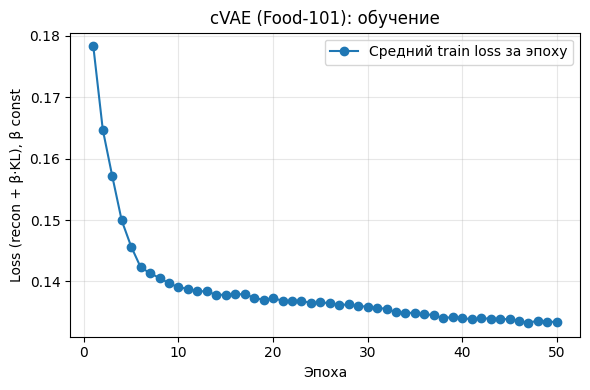

In [8]:
plt.figure(figsize=FIG_CURVE)
plt.plot(np.arange(1, len(cvae_history) + 1), cvae_history, marker="o", label="Средний train loss за эпоху")
plt.xlabel("Эпоха")
plt.ylabel("Loss (recon + β·KL), β const")
plt.title("cVAE (Food-101): обучение")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## П. 5. Условная генерация и смесь классов

**Текст пункта из условия:** Обучите выбранную модель условно генерировать изображения. Провизуализируйте результат. Сгенерируйте изображения из смеси классов.

`z ~ N(0,I)`, метка `y` задаёт класс в декодере `p(x|z,y)`.


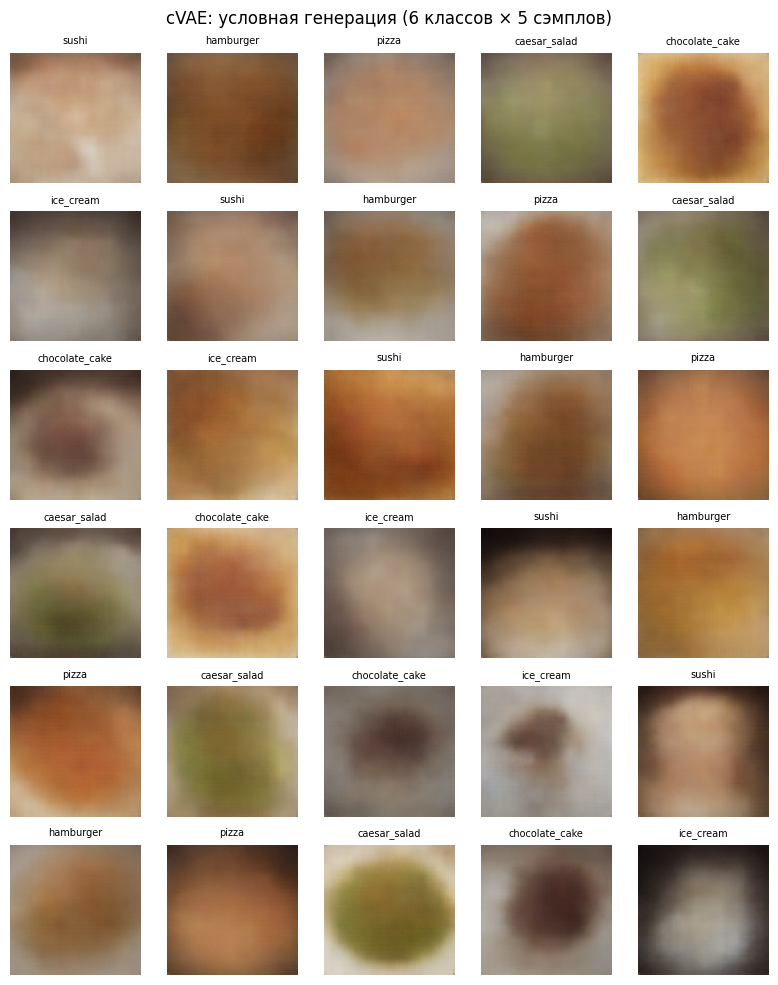

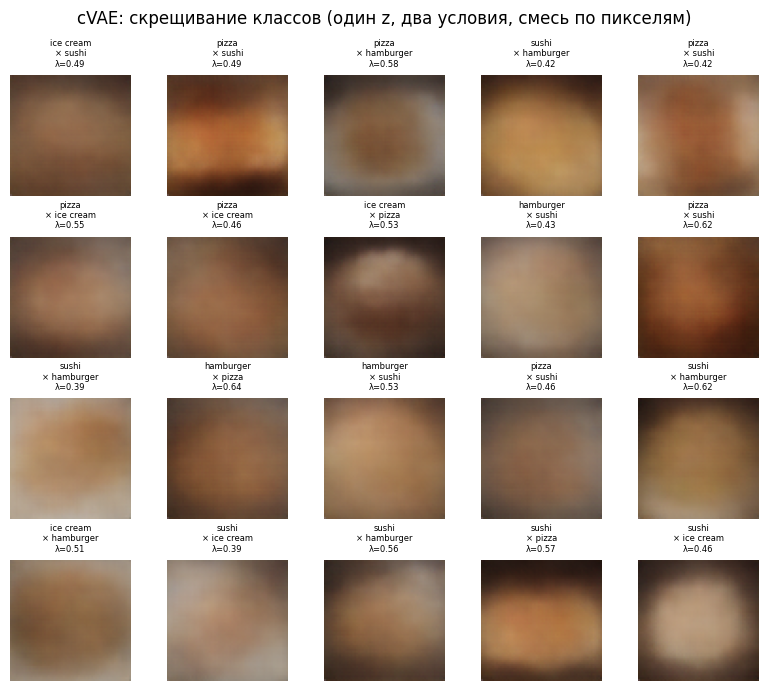

In [9]:
cvae.eval()
_rows = (GEN_CLASS_MAX - GEN_CLASS_MIN + 1) * SAMPLES_PER_GEN_CLASS // GEN_GRID_COLS
with torch.inference_mode():
    class_grid_labels = torch.tensor(
        list(range(GEN_CLASS_MIN, GEN_CLASS_MAX + 1)) * SAMPLES_PER_GEN_CLASS,
        device=device,
    )
    # Более «спокойное» сэмплирование из prior обычно даёт меньше шумовых артефактов.
    z = GEN_TEMPERATURE * torch.randn(class_grid_labels.size(0), Z_DIM, device=device)
    generated = cvae.decode(z, class_grid_labels)

fig, axes = plt.subplots(_rows, GEN_GRID_COLS, figsize=(8, 10))
for idx in range(generated.size(0)):
    row = idx // GEN_GRID_COLS
    col = idx % GEN_GRID_COLS
    axes[row, col].imshow(tensor_chw_to_numpy_hwc(generated[idx]))
    axes[row, col].axis("off")
    cid = int(class_grid_labels[idx].item())
    axes[row, col].set_title(CLASS_NAMES[cid][:16], fontsize=7)
plt.suptitle("cVAE: условная генерация (6 классов × 5 сэмплов)")
plt.tight_layout()
plt.show()

# Скрещивание классов: один и тот же z, два decode для двух разных классов из MIX_POOL_CLASSES,
# затем линейная смесь двух картинок в RGB (интерпретация «на стыке» двух условий).
with torch.inference_mode():
    mix_pool = torch.tensor(MIX_POOL_CLASSES, device=device)
    assert mix_pool.numel() >= 2, "В MIX_POOL_CLASSES нужно минимум 2 класса"

    mix_samples_rows: list[torch.Tensor] = []
    mix_pair_names: list[tuple[str, str, float]] = []

    for _ in range(N_MIX_SAMPLES):
        z_one = GEN_TEMPERATURE * torch.randn(1, Z_DIM, device=device)
        pair_idx = torch.randperm(mix_pool.numel(), device=device)[:2]
        y1 = mix_pool[pair_idx[0]].reshape(1)
        y2 = mix_pool[pair_idx[1]].reshape(1)
        lam = float(torch.empty((), device=device).uniform_(0.35, 0.65).item())

        img1 = cvae.decode(z_one, y1)
        img2 = cvae.decode(z_one, y2)
        blend = (1.0 - lam) * img1 + lam * img2

        mix_samples_rows.append(blend.squeeze(0))
        i1 = int(y1.item())
        i2 = int(y2.item())
        mix_pair_names.append((CLASS_NAMES[i1], CLASS_NAMES[i2], lam))

    mix_samples = torch.stack(mix_samples_rows, dim=0)


def _short_class(name: str, limit: int = 13) -> str:
    return name.replace("_", " ")[:limit]


_rows_mix = N_MIX_SAMPLES // GEN_GRID_COLS
fig, axes = plt.subplots(_rows_mix, GEN_GRID_COLS, figsize=(8, 7))
for idx in range(N_MIX_SAMPLES):
    row = idx // GEN_GRID_COLS
    col = idx % GEN_GRID_COLS
    axes[row, col].imshow(tensor_chw_to_numpy_hwc(mix_samples[idx]))
    axes[row, col].axis("off")
    n1, n2, lam = mix_pair_names[idx]
    axes[row, col].set_title(f"{_short_class(n1)}\n× {_short_class(n2)}\nλ={lam:.2f}", fontsize=6)
plt.suptitle("cVAE: скрещивание классов (один z, два условия, смесь по пикселям)")
plt.tight_layout()
plt.show()
